# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 6 — Performance Analytics & Attribution

Block 6 evaluates the four core portfolios produced by Block 5:

- **SPY** — passive market benchmark
- **Strategic_IV** — 52-week inverse-volatility sector portfolio
- **TSMOM_12M** — inverse-volatility portfolio with conventional 12-month TSMOM tilts
- **State_Dependent** — inverse-volatility portfolio with state-dependent active tilts

The block computes the pre-specified performance metrics:

- cumulative return
- CAGR
- annualized volatility
- Sharpe ratio
- Sortino ratio
- maximum drawdown
- Calmar ratio
- turnover
- tracking error vs SPY
- information ratio vs SPY

It also performs attribution in two layers:

1. **Active-strategy contribution relative to the strategic inverse-volatility baseline**
2. **Relative performance of the state-dependent strategy vs the TSMOM benchmark**

No new strategy parameters are introduced in this block.


In [1]:
# ============================================================
# BLOCK 6.1 — ENVIRONMENT, DRIVE & PRIOR MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "root": PROJECT_ROOT,
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "outputs": PROJECT_ROOT / "outputs",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

BLOCK1_MANIFEST = DIRS["manifests"] / "block_1_research_configuration.json"
BLOCK2_MANIFEST = DIRS["manifests"] / "block_2_universe_data_weights.json"
BLOCK3_MANIFEST = DIRS["manifests"] / "block_3_signal_engine.json"
BLOCK4_MANIFEST = DIRS["manifests"] / "block_4_state_active_weights.json"
BLOCK5_MANIFEST = DIRS["manifests"] / "block_5_portfolio_engine.json"

for p in [
    BLOCK1_MANIFEST,
    BLOCK2_MANIFEST,
    BLOCK3_MANIFEST,
    BLOCK4_MANIFEST,
    BLOCK5_MANIFEST,
]:
    if not p.exists():
        raise FileNotFoundError(f"Required prior manifest not found: {p}")

with open(BLOCK1_MANIFEST, "r", encoding="utf-8") as f:
    block1 = json.load(f)

with open(BLOCK2_MANIFEST, "r", encoding="utf-8") as f:
    block2 = json.load(f)

with open(BLOCK3_MANIFEST, "r", encoding="utf-8") as f:
    block3 = json.load(f)

with open(BLOCK4_MANIFEST, "r", encoding="utf-8") as f:
    block4 = json.load(f)

with open(BLOCK5_MANIFEST, "r", encoding="utf-8") as f:
    block5 = json.load(f)

CONFIG = block1["research_config"]

assert block5["strategic_weight_method"] == "INVERSE_VOLATILITY_52W"
assert block5["execution_convention"]["same_holding_periods_for_all_strategies"] is True

print("Loaded and validated Blocks 1–5.")
print(
    "Realized return window:",
    block5["realized_return_execution_start"],
    "to",
    block5["realized_return_execution_end"],
)


Mounted at /content/drive
Loaded and validated Blocks 1–5.
Realized return window: 2019-06-24 to 2026-08-24


In [2]:
# ============================================================
# BLOCK 6.2 — IMPORTS & LOAD BLOCK 5 OUTPUTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

PORTFOLIO_RETURNS_PATH = Path(
    block5["saved_files"]["portfolio_returns"]
)
TURNOVER_PATH = Path(
    block5["saved_files"]["portfolio_turnover"]
)
WEALTH_PATH = Path(
    block5["saved_files"]["wealth_index"]
)

for p in [
    PORTFOLIO_RETURNS_PATH,
    TURNOVER_PATH,
    WEALTH_PATH,
]:
    if not p.exists():
        raise FileNotFoundError(f"Required Block 5 file not found: {p}")

portfolio_returns = pd.read_parquet(PORTFOLIO_RETURNS_PATH)
turnover = pd.read_parquet(TURNOVER_PATH)
wealth_index = pd.read_parquet(WEALTH_PATH)

for obj in [portfolio_returns, turnover, wealth_index]:
    obj.index = pd.to_datetime(obj.index)
    obj.sort_index(inplace=True)

EXPECTED_PORTFOLIOS = [
    "SPY",
    "Strategic_IV",
    "TSMOM_12M",
    "State_Dependent",
]

missing = set(EXPECTED_PORTFOLIOS).difference(portfolio_returns.columns)
if missing:
    raise ValueError(f"Missing portfolio return columns: {sorted(missing)}")

assert portfolio_returns[EXPECTED_PORTFOLIOS].notna().all().all()

print(f"Weekly realized observations: {len(portfolio_returns):,}")
print(
    "Signal-week index range:",
    portfolio_returns.index.min().date(),
    "to",
    portfolio_returns.index.max().date(),
)


Weekly realized observations: 374
Signal-week index range: 2019-06-21 to 2026-08-14


## Annualization convention

Returns are measured over execution-to-execution weekly holding periods. Block 6 therefore uses:

- **52 periods per year** for annualized volatility, Sharpe, Sortino, tracking error, and turnover;
- exact elapsed calendar time between the first and last realized execution dates for CAGR.

The default risk-free rate is set to **0%** for the initial comparison. This keeps the experiment focused on relative strategy behavior and avoids introducing a separate cash-rate data series at this stage.


In [3]:
# ============================================================
# BLOCK 6.3 — PERFORMANCE-METRIC FUNCTIONS
# ============================================================

PERIODS_PER_YEAR = 52
RISK_FREE_RATE_ANNUAL = 0.0

REALIZED_EXECUTION_START = pd.Timestamp(
    block5["realized_return_execution_start"]
)
REALIZED_EXECUTION_END = pd.Timestamp(
    block5["realized_return_execution_end"]
)

elapsed_years = (
    (REALIZED_EXECUTION_END - REALIZED_EXECUTION_START).days
    / 365.2425
)

if elapsed_years <= 0:
    raise ValueError("Invalid realized execution window.")


def cumulative_return(r: pd.Series) -> float:
    return float((1.0 + r).prod() - 1.0)


def cagr(r: pd.Series, years: float) -> float:
    terminal = float((1.0 + r).prod())
    if terminal <= 0:
        return np.nan
    return terminal ** (1.0 / years) - 1.0


def annualized_volatility(r: pd.Series) -> float:
    return float(r.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR))


def annualized_return_arithmetic(r: pd.Series) -> float:
    return float(r.mean() * PERIODS_PER_YEAR)


def sharpe_ratio(r: pd.Series) -> float:
    rf_weekly = (1.0 + RISK_FREE_RATE_ANNUAL) ** (1.0 / PERIODS_PER_YEAR) - 1.0
    excess = r - rf_weekly
    vol = excess.std(ddof=1)
    if vol == 0 or pd.isna(vol):
        return np.nan
    return float(
        excess.mean() / vol * np.sqrt(PERIODS_PER_YEAR)
    )


def sortino_ratio(r: pd.Series) -> float:
    rf_weekly = (1.0 + RISK_FREE_RATE_ANNUAL) ** (1.0 / PERIODS_PER_YEAR) - 1.0
    excess = r - rf_weekly
    downside = excess[excess < 0]
    if len(downside) == 0:
        return np.nan
    downside_dev = np.sqrt((downside ** 2).mean())
    if downside_dev == 0 or pd.isna(downside_dev):
        return np.nan
    return float(
        excess.mean() / downside_dev * np.sqrt(PERIODS_PER_YEAR)
    )


def drawdown_series(r: pd.Series) -> pd.Series:
    wealth = (1.0 + r).cumprod()
    peak = wealth.cummax()
    return wealth / peak - 1.0


def maximum_drawdown(r: pd.Series) -> float:
    return float(drawdown_series(r).min())


def calmar_ratio(r: pd.Series, years: float) -> float:
    g = cagr(r, years)
    mdd = maximum_drawdown(r)
    if mdd == 0 or pd.isna(mdd):
        return np.nan
    return float(g / abs(mdd))


def tracking_error_vs_benchmark(
    r: pd.Series,
    benchmark: pd.Series,
) -> float:
    active = r - benchmark
    return float(
        active.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
    )


def information_ratio_vs_benchmark(
    r: pd.Series,
    benchmark: pd.Series,
) -> float:
    active = r - benchmark
    te = active.std(ddof=1)
    if te == 0 or pd.isna(te):
        return np.nan
    return float(
        active.mean() / te * np.sqrt(PERIODS_PER_YEAR)
    )


In [4]:
# ============================================================
# BLOCK 6.4 — CORE PERFORMANCE TABLE
# ============================================================

rows = []

for name in EXPECTED_PORTFOLIOS:
    r = portfolio_returns[name].dropna()

    rows.append(
        {
            "Portfolio": name,
            "Cumulative Return": cumulative_return(r),
            "CAGR": cagr(r, elapsed_years),
            "Annualized Return (Arithmetic)": annualized_return_arithmetic(r),
            "Annualized Volatility": annualized_volatility(r),
            "Sharpe": sharpe_ratio(r),
            "Sortino": sortino_ratio(r),
            "Max Drawdown": maximum_drawdown(r),
            "Calmar": calmar_ratio(r, elapsed_years),
            "Tracking Error vs SPY": (
                0.0
                if name == "SPY"
                else tracking_error_vs_benchmark(
                    r,
                    portfolio_returns["SPY"],
                )
            ),
            "Information Ratio vs SPY": (
                np.nan
                if name == "SPY"
                else information_ratio_vs_benchmark(
                    r,
                    portfolio_returns["SPY"],
                )
            ),
        }
    )

performance_summary = (
    pd.DataFrame(rows)
    .set_index("Portfolio")
)

display(performance_summary)


,Cumulative Return,CAGR,Annualized Return (Arithmetic),Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Tracking Error vs SPY,Information Ratio vs SPY
Portfolio,,,,,,,,,,
SPY,1.879664,0.159001,0.164586,0.186192,0.883955,0.825773,-0.334003,0.476045,0.000000,NaN
Strategic_IV,1.343816,0.126183,0.133272,0.171515,0.777031,0.680130,-0.351040,0.359454,0.060017,-0.521742
TSMOM_12M,1.350249,0.126613,0.133208,0.168967,0.788368,0.694136,-0.345465,0.366501,0.059851,-0.524259
State_Dependent,1.559913,0.140125,0.145917,0.173575,0.840655,0.741352,-0.351040,0.399170,0.062629,-0.298084


In [5]:
# ============================================================
# BLOCK 6.5 — TURNOVER METRICS
# ============================================================

turnover_metrics = pd.DataFrame(index=[
    "Strategic_IV",
    "TSMOM_12M",
    "State_Dependent",
])

turnover_metrics["Mean Weekly Turnover"] = turnover.mean()
turnover_metrics["Median Weekly Turnover"] = turnover.median()
turnover_metrics["Maximum Weekly Turnover"] = turnover.max()
turnover_metrics["Annualized Turnover Approx"] = (
    turnover.mean() * PERIODS_PER_YEAR
)

display(turnover_metrics)


,Mean Weekly Turnover,Median Weekly Turnover,Maximum Weekly Turnover,Annualized Turnover Approx
Strategic_IV,0.005964,0.004450,0.044502,0.310154
TSMOM_12M,0.026070,0.011320,0.139095,1.355629
State_Dependent,0.011788,0.010025,0.084673,0.612997


In [6]:
# ============================================================
# BLOCK 6.6 — RELATIVE PERFORMANCE VS STRATEGIC BASELINE
# ============================================================

strategic_base = portfolio_returns["Strategic_IV"]

active_vs_strategic = pd.DataFrame(
    {
        "TSMOM_12M": (
            portfolio_returns["TSMOM_12M"]
            - strategic_base
        ),
        "State_Dependent": (
            portfolio_returns["State_Dependent"]
            - strategic_base
        ),
    },
    index=portfolio_returns.index,
)

relative_rows = []

for name in active_vs_strategic.columns:
    ar = active_vs_strategic[name]

    relative_rows.append(
        {
            "Strategy": name,
            "Annualized Active Return vs Strategic": (
                ar.mean() * PERIODS_PER_YEAR
            ),
            "Tracking Error vs Strategic": (
                ar.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
            ),
            "Information Ratio vs Strategic": (
                ar.mean() / ar.std(ddof=1)
                * np.sqrt(PERIODS_PER_YEAR)
                if ar.std(ddof=1) != 0
                else np.nan
            ),
            "Positive Active Weeks": float((ar > 0).mean()),
            "Negative Active Weeks": float((ar < 0).mean()),
        }
    )

relative_vs_strategic_summary = (
    pd.DataFrame(relative_rows)
    .set_index("Strategy")
)

display(relative_vs_strategic_summary)


,Annualized Active Return vs Strategic,Tracking Error vs Strategic,Information Ratio vs Strategic,Positive Active Weeks,Negative Active Weeks
Strategy,,,,,
TSMOM_12M,-0.000064,0.009119,-0.007002,0.425134,0.401070
State_Dependent,0.012645,0.016182,0.781392,0.489305,0.417112


In [7]:
# ============================================================
# BLOCK 6.7 — STATE-DEPENDENT VS TSMOM RELATIVE PERFORMANCE
# ============================================================

state_minus_tsmom = (
    portfolio_returns["State_Dependent"]
    - portfolio_returns["TSMOM_12M"]
).rename("State_minus_TSMOM")

state_vs_tsmom_summary = pd.Series(
    {
        "Annualized Relative Return": (
            state_minus_tsmom.mean() * PERIODS_PER_YEAR
        ),
        "Relative Volatility": (
            state_minus_tsmom.std(ddof=1)
            * np.sqrt(PERIODS_PER_YEAR)
        ),
        "Information Ratio": (
            state_minus_tsmom.mean()
            / state_minus_tsmom.std(ddof=1)
            * np.sqrt(PERIODS_PER_YEAR)
            if state_minus_tsmom.std(ddof=1) != 0
            else np.nan
        ),
        "State-Dependent Outperformance Weeks": (
            (state_minus_tsmom > 0).mean()
        ),
        "TSMOM Outperformance Weeks": (
            (state_minus_tsmom < 0).mean()
        ),
    },
    name="State-Dependent vs TSMOM",
).to_frame()

display(state_vs_tsmom_summary)


,State-Dependent vs TSMOM
Annualized Relative Return,0.012709
Relative Volatility,0.017991
Information Ratio,0.706373
State-Dependent Outperformance Weeks,0.508021
TSMOM Outperformance Weeks,0.483957


## Sector-level attribution

The portfolio engine already provides the common sector holding-period return matrix and the three sector-weight sets. Block 6 uses those to decompose each active strategy's weekly return difference versus the strategic inverse-volatility portfolio:

\[
Contribution_{i,t}
=
(w^{strategy}_{i,t}-w^{strategic}_{i,t})R_{i,t}
\]

Summing across sectors gives the exact weekly active return difference under the common holding-period return convention.


In [8]:
# ============================================================
# BLOCK 6.8 — LOAD WEIGHTS & SECTOR RETURNS FOR ATTRIBUTION
# ============================================================

SECTOR_RETURN_PATH = Path(
    block5["saved_files"]["sector_holding_returns"]
)
TSMOM_WEIGHT_PATH = Path(
    block5["saved_files"]["tsmom_target_weights"]
)
STATE_WEIGHT_PATH = Path(
    block4["saved_files"]["canonical_target_weights_wide"]
)
STRATEGIC_WEIGHT_PATH = Path(
    block2["saved_files"]["strategic_weights"]
)

for p in [
    SECTOR_RETURN_PATH,
    TSMOM_WEIGHT_PATH,
    STATE_WEIGHT_PATH,
    STRATEGIC_WEIGHT_PATH,
]:
    if not p.exists():
        raise FileNotFoundError(f"Attribution input not found: {p}")

sector_returns = pd.read_parquet(SECTOR_RETURN_PATH)
tsmom_weights = pd.read_parquet(TSMOM_WEIGHT_PATH)
state_weights = pd.read_parquet(STATE_WEIGHT_PATH)
strategic_weights = pd.read_parquet(STRATEGIC_WEIGHT_PATH)

for obj in [
    sector_returns,
    tsmom_weights,
    state_weights,
    strategic_weights,
]:
    obj.index = pd.to_datetime(obj.index)
    obj.sort_index(inplace=True)

sector_cols = sector_returns.columns.tolist()

realized_index = sector_returns.index

tsmom_w = tsmom_weights.reindex(
    index=realized_index,
    columns=sector_cols,
)
state_w = state_weights.reindex(
    index=realized_index,
    columns=sector_cols,
)
strategic_w = strategic_weights.reindex(
    index=realized_index,
    columns=sector_cols,
)

for name, w in {
    "TSMOM": tsmom_w,
    "State-dependent": state_w,
    "Strategic": strategic_w,
}.items():
    if w.isna().any().any():
        raise ValueError(
            f"{name} weights missing in attribution window."
        )


In [9]:
# ============================================================
# BLOCK 6.9 — SECTOR ATTRIBUTION VS STRATEGIC BASELINE
# ============================================================

tsmom_sector_contrib = (
    (tsmom_w - strategic_w)
    * sector_returns
)

state_sector_contrib = (
    (state_w - strategic_w)
    * sector_returns
)

# Exact reconciliation to weekly active return differences.
tsmom_recon = (
    tsmom_sector_contrib.sum(axis=1)
    - (
        portfolio_returns["TSMOM_12M"]
        - portfolio_returns["Strategic_IV"]
    )
)

state_recon = (
    state_sector_contrib.sum(axis=1)
    - (
        portfolio_returns["State_Dependent"]
        - portfolio_returns["Strategic_IV"]
    )
)

assert np.allclose(
    tsmom_recon.values,
    0.0,
    atol=1e-12,
)
assert np.allclose(
    state_recon.values,
    0.0,
    atol=1e-12,
)

sector_attribution_summary = pd.DataFrame(
    {
        "TSMOM_Total_Active_Contribution": (
            tsmom_sector_contrib.sum(axis=0)
        ),
        "State_Total_Active_Contribution": (
            state_sector_contrib.sum(axis=0)
        ),
        "TSMOM_Annualized_Active_Contribution_Approx": (
            tsmom_sector_contrib.mean(axis=0)
            * PERIODS_PER_YEAR
        ),
        "State_Annualized_Active_Contribution_Approx": (
            state_sector_contrib.mean(axis=0)
            * PERIODS_PER_YEAR
        ),
    }
)

sector_attribution_summary.index.name = "Ticker"

display(
    sector_attribution_summary.sort_values(
        "State_Total_Active_Contribution",
        ascending=False,
    )
)


,TSMOM_Total_Active_Contribution,State_Total_Active_Contribution,TSMOM_Annualized_Active_Contribution_Approx,State_Annualized_Active_Contribution_Approx
Ticker,,,,
XLI,0.006464,0.043663,0.000899,0.006071
XLE,0.006375,0.036317,0.000886,0.005049
XLC,0.012510,0.030818,0.001739,0.004285
XLY,0.009999,0.010650,0.001390,0.001481
XLRE,-0.021535,0.008161,-0.002994,0.001135
XLB,0.001756,0.007169,0.000244,0.000997
XLU,-0.010062,0.004341,-0.001399,0.000604
XLV,-0.007870,-0.006990,-0.001094,-0.000972
XLP,-0.003366,-0.007998,-0.000468,-0.001112


In [10]:
# ============================================================
# BLOCK 6.10 — DRAWNDOWN TABLE
# ============================================================

drawdowns = pd.DataFrame(
    {
        name: drawdown_series(
            portfolio_returns[name]
        )
        for name in EXPECTED_PORTFOLIOS
    }
)

drawdown_summary = pd.DataFrame(
    {
        "Maximum Drawdown": drawdowns.min(),
        "Drawdown Week": drawdowns.idxmin(),
    }
)

display(drawdown_summary)


,Maximum Drawdown,Drawdown Week
SPY,-0.334003,2020-03-13
Strategic_IV,-0.351040,2020-03-13
TSMOM_12M,-0.345465,2020-03-13
State_Dependent,-0.351040,2020-03-13


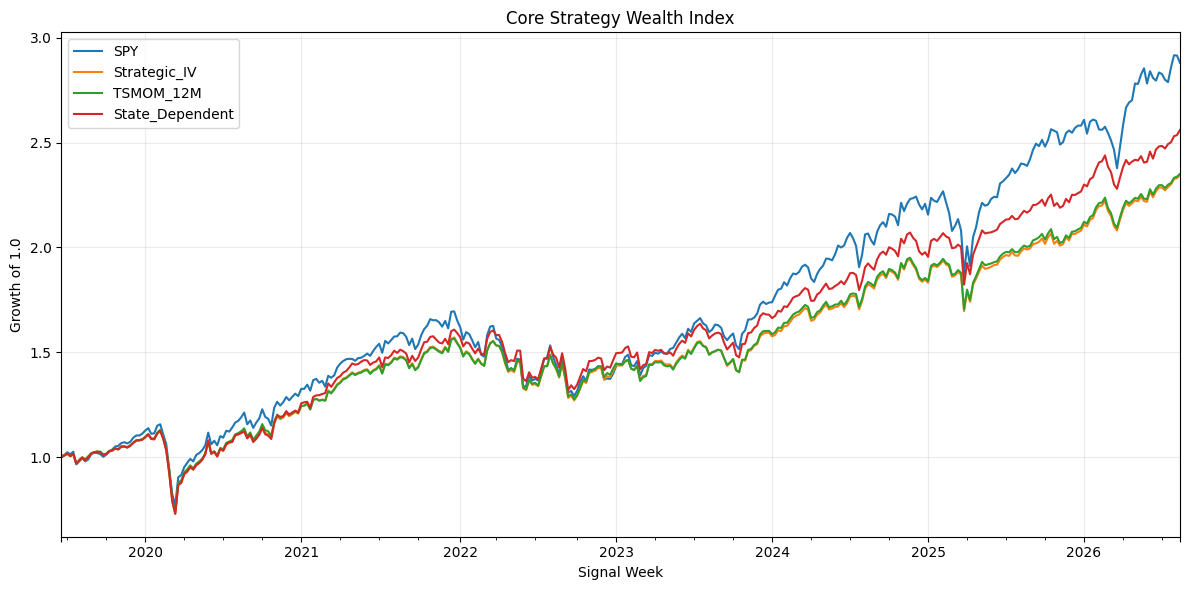

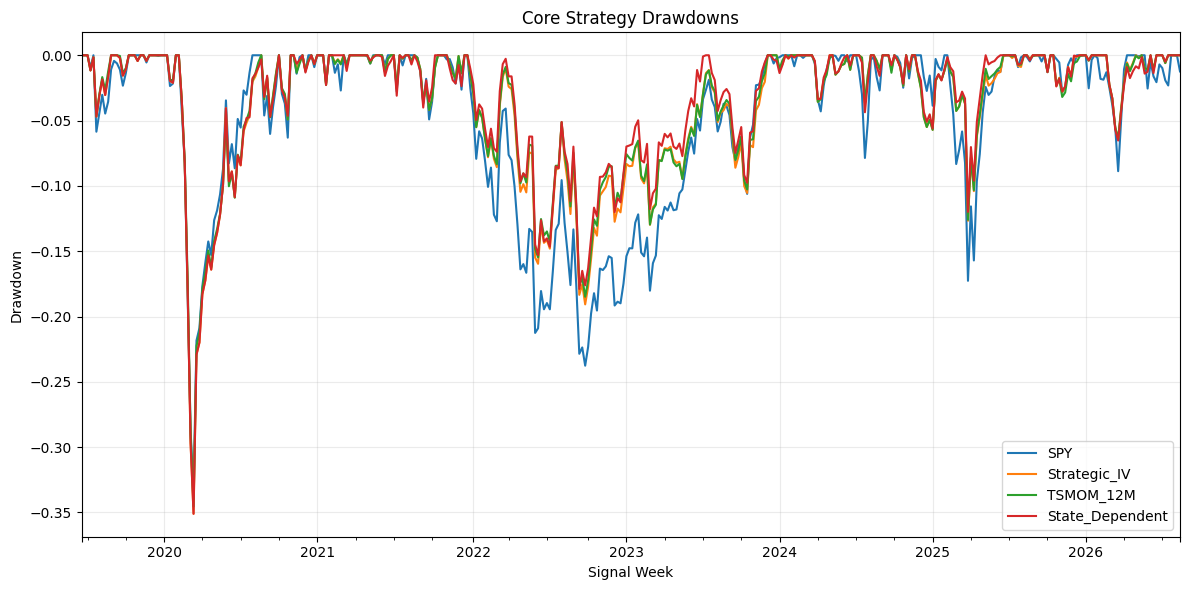

In [11]:
# ============================================================
# BLOCK 6.11 — CORE FIGURES
# ============================================================

# Wealth index
fig, ax = plt.subplots(figsize=(12, 6))
wealth = (1.0 + portfolio_returns[EXPECTED_PORTFOLIOS]).cumprod()
wealth.plot(ax=ax)
ax.set_title("Core Strategy Wealth Index")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Growth of 1.0")
ax.grid(True, alpha=0.25)
fig.tight_layout()

WEALTH_FIG_PATH = DIRS["figures"] / "block_6_wealth_index.png"
fig.savefig(WEALTH_FIG_PATH, dpi=180, bbox_inches="tight")
plt.show()

# Drawdowns
fig, ax = plt.subplots(figsize=(12, 6))
drawdowns.plot(ax=ax)
ax.set_title("Core Strategy Drawdowns")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25)
fig.tight_layout()

DRAWDOWN_FIG_PATH = DIRS["figures"] / "block_6_drawdowns.png"
fig.savefig(DRAWDOWN_FIG_PATH, dpi=180, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# BLOCK 6.12 — SAVE ANALYTICS OUTPUTS
# ============================================================

PERFORMANCE_TABLE_PATH = (
    DIRS["tables"] / "block_6_performance_summary.csv"
)

TURNOVER_TABLE_PATH = (
    DIRS["tables"] / "block_6_turnover_metrics.csv"
)

RELATIVE_STRATEGIC_PATH = (
    DIRS["tables"]
    / "block_6_relative_vs_strategic_summary.csv"
)

STATE_VS_TSMOM_PATH = (
    DIRS["tables"]
    / "block_6_state_vs_tsmom_summary.csv"
)

SECTOR_ATTRIBUTION_PATH = (
    DIRS["tables"]
    / "block_6_sector_attribution_vs_strategic.csv"
)

DRAWDOWN_SUMMARY_PATH = (
    DIRS["tables"]
    / "block_6_drawdown_summary.csv"
)

DRAWDOWN_SERIES_PATH = (
    DIRS["data_processed"]
    / "weekly_drawdown_series_core_strategies.parquet"
)

ACTIVE_RELATIVE_RETURNS_PATH = (
    DIRS["data_processed"]
    / "weekly_active_returns_vs_strategic.parquet"
)

SECTOR_ATTRIBUTION_WEEKLY_PATH = (
    DIRS["data_processed"]
    / "weekly_sector_attribution_state_vs_strategic.parquet"
)

performance_summary.to_csv(PERFORMANCE_TABLE_PATH)
turnover_metrics.to_csv(TURNOVER_TABLE_PATH)
relative_vs_strategic_summary.to_csv(RELATIVE_STRATEGIC_PATH)
state_vs_tsmom_summary.to_csv(STATE_VS_TSMOM_PATH)
sector_attribution_summary.to_csv(SECTOR_ATTRIBUTION_PATH)
drawdown_summary.to_csv(DRAWDOWN_SUMMARY_PATH)

drawdowns.to_parquet(DRAWDOWN_SERIES_PATH)
active_vs_strategic.to_parquet(ACTIVE_RELATIVE_RETURNS_PATH)
state_sector_contrib.to_parquet(SECTOR_ATTRIBUTION_WEEKLY_PATH)

print("Saved Block 6 analytics outputs.")


Saved Block 6 analytics outputs.


In [13]:
# ============================================================
# BLOCK 6.13 — SAVE BLOCK 6 MANIFEST
# ============================================================

block6_manifest = {
    "project": block1["project"],
    "block": "Block 6 - Performance Analytics & Attribution",
    "created_utc": datetime.now(timezone.utc).isoformat(),

    "annualization": {
        "periods_per_year": PERIODS_PER_YEAR,
        "risk_free_rate_annual": RISK_FREE_RATE_ANNUAL,
        "cagr_elapsed_years": elapsed_years,
    },

    "realized_execution_window": {
        "start": str(REALIZED_EXECUTION_START.date()),
        "end": str(REALIZED_EXECUTION_END.date()),
    },

    "metrics": [
        "Cumulative Return",
        "CAGR",
        "Annualized Return (Arithmetic)",
        "Annualized Volatility",
        "Sharpe",
        "Sortino",
        "Max Drawdown",
        "Calmar",
        "Tracking Error vs SPY",
        "Information Ratio vs SPY",
        "Turnover",
    ],

    "attribution": {
        "baseline": "Strategic_IV",
        "strategies": [
            "TSMOM_12M",
            "State_Dependent",
        ],
        "sector_contribution_formula": (
            "(strategy_weight - strategic_weight) * sector_return"
        ),
        "weekly_reconciliation_checked": True,
    },

    "saved_files": {
        "performance_summary": str(PERFORMANCE_TABLE_PATH),
        "turnover_metrics": str(TURNOVER_TABLE_PATH),
        "relative_vs_strategic": str(RELATIVE_STRATEGIC_PATH),
        "state_vs_tsmom": str(STATE_VS_TSMOM_PATH),
        "sector_attribution": str(SECTOR_ATTRIBUTION_PATH),
        "drawdown_summary": str(DRAWDOWN_SUMMARY_PATH),
        "drawdown_series": str(DRAWDOWN_SERIES_PATH),
        "active_returns_vs_strategic": str(ACTIVE_RELATIVE_RETURNS_PATH),
        "state_sector_attribution_weekly": str(SECTOR_ATTRIBUTION_WEEKLY_PATH),
        "wealth_figure": str(WEALTH_FIG_PATH),
        "drawdown_figure": str(DRAWDOWN_FIG_PATH),
    },
}

BLOCK6_MANIFEST = (
    DIRS["manifests"] / "block_6_performance_analytics.json"
)

with open(BLOCK6_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(block6_manifest, f, indent=2)

print("Saved Block 6 manifest:")
print(BLOCK6_MANIFEST)


Saved Block 6 manifest:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/manifests/block_6_performance_analytics.json


In [14]:
# ============================================================
# BLOCK 6.14 — FINAL STATUS
# ============================================================

summary = pd.Series(
    {
        "Portfolios analyzed": len(EXPECTED_PORTFOLIOS),
        "Weekly realized observations": len(portfolio_returns),
        "Realized execution start": REALIZED_EXECUTION_START.date(),
        "Realized execution end": REALIZED_EXECUTION_END.date(),
        "Elapsed years for CAGR": round(elapsed_years, 4),
        "Periods per year": PERIODS_PER_YEAR,
        "Risk-free rate": RISK_FREE_RATE_ANNUAL,
        "Performance table complete": bool(
            performance_summary.notna()
            .drop(columns=["Information Ratio vs SPY"])
            .all()
            .all()
        ),
        "Attribution reconciliation passed": bool(
            np.allclose(tsmom_recon.values, 0.0, atol=1e-12)
            and np.allclose(state_recon.values, 0.0, atol=1e-12)
        ),
        "Wealth figure saved": WEALTH_FIG_PATH.exists(),
        "Drawdown figure saved": DRAWDOWN_FIG_PATH.exists(),
    },
    name="Block 6 status",
).to_frame()

display(summary)

print("\nBLOCK 6 COMPLETE")
print("Next: Block 7 — Visual Diagnostics & Research Interpretation")


,Block 6 status
Portfolios analyzed,4
Weekly realized observations,374
Realized execution start,2019-06-24
Realized execution end,2026-08-24
Elapsed years for CAGR,7.1678
Periods per year,52
Risk-free rate,0.0
Performance table complete,True
Attribution reconciliation passed,True
Wealth figure saved,True



BLOCK 6 COMPLETE
Next: Block 7 — Visual Diagnostics & Research Interpretation
